# MGS-9 - Trouver l'Everest : relief reel et bassins d'attraction

**Serie MetaGeneticSharp** | Precedent : [MGS-8 - Landscape Explorer](MGS-8-LandscapeExplorer.ipynb)

MGS-8 explorait des paysages de fitness *synthetiques* (Sphere, Rastrigin...). Ici le
paysage est un **relief terrestre reel** : on cherche le point le plus haut - l'Everest - sur
quatre cartes d'altitude a zoom croissant, du globe entier a la region du sommet.

## Objectifs d'apprentissage

- Traiter une carte d'altitude (DEM) comme un **paysage de fitness a maximiser**.
- Visualiser le relief en **heatmap graphique PNG** (sommet = marqueur noir), coherent avec le
  rendu de MGS-8 via le `LandscapeRenderer` du fork.
- Lancer le **moteur MGS** (GA / WOA / Equilibrium Optimizer) sur ce relief, plus une
  **baseline PSO** externe, a budget d'evaluations egal.
- Mesurer le **taux de reussite** de chaque methode pour localiser le sommet, et relier ce
  taux au rapport **taille du bassin d'attraction / taille de l'espace de recherche**.

## Prerequis

- MGS-1 a MGS-5 (moteur, compounds geometriques WOA/EO), MGS-8 (heatmaps PNG via le fork).
- Build du fork : `dotnet build c:/dev/MetaGeneticSharp/MetaGeneticSharp.sln`.

## Donnees

Les **cartes d'altitude originales de jsboige** (`KnownHeightMap` : `World`, `TibetanPlateau`,
`NepalBhoutan`, `EverestMount`), acquisitions d'un service d'elevation WMS conservees en PNG
d'environ **2560 px**, **exactement telles qu'elles vivent dans la librairie MGS** (ressources
embarquees du fork `MetaGeneticSharp.Extensions`). Aucun appel reseau a l'execution : on lit les
PNG verbatim via `ImageHeightMapFunction` (niveaux de gris, interpolation inverse-distance,
byte-exact @ `d05826fd`). L'altitude y est codee en **niveau de gris** (clair = haut) ; on
cherche le pixel le plus clair de chaque carte, c'est-a-dire le sommet.

> **Note d'auteur (AUTHORSHIP).** Ce notebook est un *habillage pedagogique* : il consomme la
> librairie MGS (moteur, WhaleOptimisationAlgorithm, EquilibriumOptimizer, KnownFunctionGenes,
> LandscapeRenderer / SkiaLandscapeRenderer, `LandscapeMaps.CreateFunction` / `KnownHeightMap`)
> sans la reimplementer. Les cartes d'altitude sont les ressources PNG verbatim de jsboige. Le
> PSO est une baseline externe explicite (le bestiaire du fork n'a pas de PSO), au meme titre
> que le RandomSearchOptimizer de la lib.

*Duree estimee : 25-35 min.*


In [1]:
// MetaGeneticSharp + GeneticSharp DLLs from the fork's self-contained Extensions output
// (one-stop dir: it also ships System.Drawing.Common.dll and SkiaSharp.dll, needed because
//  the graphic heatmap types now encode PNG via SkiaSharp cross-platform on the fork @ 7d1575c).
// Build prerequisite: dotnet build c:/dev/MetaGeneticSharp/MetaGeneticSharp.sln
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/GeneticSharp.Infrastructure.Framework.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/GeneticSharp.Domain.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/MetaGeneticSharp.Infrastructure.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/MetaGeneticSharp.Domain.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/MetaGeneticSharp.Extensions.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/System.Drawing.Common.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/SkiaSharp.dll"

using System.Linq;
using System.Runtime.InteropServices;                   // NativeLibrary, RuntimeInformation
using MetaGeneticSharp;                                 // LandscapeRenderer, SkiaLandscapeRenderer
using GeneticSharp;                                     // GA engine, IFitness, KnownFunctionGenes

// .NET Interactive quirk: a #r to the managed SkiaSharp.dll does NOT wire up SkiaSharp's
// runtimes/<rid>/native/ probing, so the first Skia call would P/Invoke a native lib that was
// never loaded (BadImageFormatException 0x8007000B). Preload the arch-matching native binary
// from the self-contained output once, up front (same fix as MGS-8, fork @ 7d1575c).
string rid = RuntimeInformation.ProcessArchitecture == Architecture.Arm64 ? "win-arm64"
           : RuntimeInformation.ProcessArchitecture == Architecture.X86   ? "win-x86"
           : "win-x64";
NativeLibrary.Load($"c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/runtimes/{rid}/native/libSkiaSharp.dll");

Console.WriteLine("Wiring OK : MetaGeneticSharp + GeneticSharp + Extensions (LandscapeRenderer + SkiaLandscapeRenderer).");
Console.WriteLine($"  Renderers : {typeof(LandscapeRenderer).Name}, {typeof(SkiaLandscapeRenderer).Name} (SkiaSharp, native rid={rid})");
Console.WriteLine($"  Engine    : {typeof(WhaleOptimisationAlgorithm).Name}, {typeof(EquilibriumOptimizer).Name}");

The below script needs to be able to find the current output cell; this is an easy method to get it.

Wiring OK : MetaGeneticSharp + GeneticSharp + Extensions (LandscapeRenderer + SkiaLandscapeRenderer).


  Renderers : LandscapeRenderer, SkiaLandscapeRenderer (SkiaSharp, native rid=win-x64)


  Engine    : WhaleOptimisationAlgorithm, EquilibriumOptimizer


## 1. Le relief reel comme paysage de fitness

Une carte d'altitude (Digital Elevation Model) code le terrain en **niveaux de gris** : un pixel
clair = un point haut, un pixel fonce = une basse. On la lit en **coordonnees normalisees**
`(u, v)` dans `[0,1]^2` : `u` parcourt la longitude (ouest -> est), `v` la latitude
(sud -> nord). Le **niveau d'altitude interpole** en `(u,v)` est notre **fonction de fitness,
a MAXIMISER** - l'inverse de MGS-6/MGS-8 ou un objectif synthetique etait minimise.
*Trouver l'Everest* = localiser le maximum global de la carte, c'est-a-dire son pixel le plus clair.

La classe `DemGrid` ci-dessous n'est qu'une **enveloppe** sur la fonction verbatim de la librairie
(`LandscapeMaps.CreateFunction` -> `ImageHeightMapFunction`) : elle mappe `(u,v)` aux coordonnees
pixel du PNG d'origine et expose le sommet ; aucune logique d'optimisation, aucun
re-echantillonnage, aucun `int[]` embarque n'y vivent.


In [2]:
using GeneticSharp.Extensions.Mathematic.Functions;   // ImageHeightMapFunction (verbatim @ d05826fd)

// A REAL-ELEVATION landscape from jsboige's verbatim height-map assets (KnownHeightMap, ~2560 px,
// originally acquired via a WMS elevation service). The fork streams them through
// ImageHeightMapFunction (grayscale elevation, inverse-distance interpolation) -- byte-exact @ d05826fd.
// No offline resampling and no int[] grid: the high-definition PNG IS the fitness field. We
// MAXIMISE the grayscale level : the brightest pixel is the highest ground, i.e. the summit.
public sealed class DemGrid : IDisposable
{
    public string Name { get; }
    public KnownHeightMap Map { get; }
    public double LatMin, LatMax, LonMin, LonMax;   // qualitative bbox (display only, from the WMS query)
    private readonly ImageHeightMapFunction _fn;
    private readonly double _w, _h;                 // pixel dimensions of the verbatim PNG
    private double _peakU, _peakV;
    public double ElevMin { get; private set; }
    public double ElevMax { get; private set; }
    public int W => (int)_w;
    public int H => (int)_h;

    public DemGrid(KnownHeightMap map, string name, double latMin, double latMax, double lonMin, double lonMax)
    {
        Map = map; Name = name;
        LatMin = latMin; LatMax = latMax; LonMin = lonMin; LonMax = lonMax;
        _fn = LandscapeMaps.CreateFunction(map);
        var ranges = _fn.Ranges(2);
        _w = ranges[0].max + 1; _h = ranges[1].max + 1;
        ScanExtrema();
    }

    // Elevation (grayscale level, brighter = higher) at normalised (u, v) in [0,1]^2. Delegates to
    // the verbatim ImageHeightMapFunction over pixel coordinates (u -> x west->east, v -> y south->north).
    public double Interp(double u, double v)
    {
        double x = Math.Clamp(u * (_w - 1), 0.0, _w - 1);
        double y = Math.Clamp(v * (_h - 1), 0.0, _h - 1);
        return _fn.Function(new[] { x, y });
    }

    // Normalised (u, v) of the brightest pixel = the search target. Found once, by dense sampling of
    // the verbatim field (the renderer samples the same field when it draws the heatmap).
    public (double u, double v, double elev) GlobalMax() => (_peakU, _peakV, ElevMax);

    private void ScanExtrema()
    {
        double min = double.PositiveInfinity, max = double.NegativeInfinity;
        const int S = 240;
        for (int i = 0; i < S; i++)
            for (int j = 0; j < S; j++)
            {
                double e = Interp((double)i / (S - 1), (double)j / (S - 1));
                if (e < min) min = e;
                if (e > max) { max = e; _peakU = (double)i / (S - 1); _peakV = (double)j / (S - 1); }
            }
        ElevMin = min; ElevMax = max;
    }

    public void Dispose() => _fn.Dispose();
}
Console.WriteLine("DemGrid defini : enveloppe sur KnownHeightMap (ImageHeightMapFunction verbatim), relief a MAXIMISER.");


DemGrid defini : enveloppe sur KnownHeightMap (ImageHeightMapFunction verbatim), relief a MAXIMISER.


In [3]:
// The four ORIGINAL jsboige height maps (KnownHeightMap, ~2560 px, verbatim fork assets). They form
// the zoom cascade Monde -> Plateau -> Himalaya -> Everest : each map is a tighter window on the
// same mountain range, so the summit sharpens as we zoom in. No embedded int[] grid, no ETOPO1
// downsample -- the faithful high-definition PNG is the landscape, read by ImageHeightMapFunction.
var world          = new DemGrid(KnownHeightMap.World,          "Monde",   -56.0,  60.0, -180.0, 180.0);
var tibetanPlateau = new DemGrid(KnownHeightMap.TibetanPlateau, "Plateau",  27.0,  45.0,   70.0, 100.0);
var himalayaArc    = new DemGrid(KnownHeightMap.NepalBhoutan,   "Himalaya", 27.0,  30.5,   83.0,  89.0);
var everestRegion  = new DemGrid(KnownHeightMap.EverestMount,   "Everest",  27.7,  28.3,   86.6,  87.2);
var grids  = new[] { world, tibetanPlateau, himalayaArc, everestRegion };
var labels = new[] { "Monde", "Plateau", "Himalaya", "Everest" };

Console.WriteLine($"{"Carte",-10}{"KnownHeightMap",-18}{"pixels",-12}{"niveau gris",-14}sommet (u, v)");
Console.WriteLine(new string('-', 74));
foreach (var g in grids)
{
    var (pu, pv, _) = g.GlobalMax();
    string px = $"{g.W}x{g.H}", gr = $"{g.ElevMin:F0}..{g.ElevMax:F0}";
    Console.WriteLine($"{g.Name,-10}{g.Map,-18}{px,-12}{gr,-14}({pu:F3}, {pv:F3})");
}
Console.WriteLine("\nLe pic se resserre avec le zoom : du globe a la region du sommet, l'objectif devient net.");


Carte     KnownHeightMap    pixels      niveau gris   sommet (u, v)


--------------------------------------------------------------------------


Monde     World             2560x1440   35..216       (0,849, 0,251)


Plateau   TibetanPlateau    2560x1383   0..219        (0,544, 0,916)


Himalaya  NepalBhoutan      2560x1383   0..251        (0,464, 0,640)


Everest   EverestMount      2560x1383   0..255        (0,498, 0,372)



Le pic se resserre avec le zoom : du globe a la region du sommet, l'objectif devient net.


## 2. Visualiser les quatre zooms

Meme **heatmap graphique PNG** que MGS-7 (le `LandscapeRenderer` du fork, rampe de couleur HSV
verbatim jsboige @ `d05826fd`), mais la **cible est inversee**. MGS-8 *minimise* ses fonctions
analytiques (l'optimum porte le marqueur blanc) ; ici on **maximise** l'altitude, donc c'est le
**maximum** - le sommet - qui porte le **marqueur noir**, cible explicite de la recherche. Les
basses terres et oceans s'etalent a une extremite de la rampe, les hauts reliefs a l'autre ; le
gradient entre les deux rend le bassin d'attraction du pic immediatement lisible. Le nord
(haute latitude) est place en haut de la carte.

Monde (World) : niveau d'altitude 35..216 | sommet = pixel le plus clair (marqueur noir)
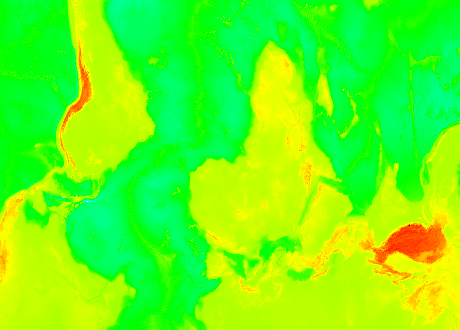

Plateau (TibetanPlateau) : niveau d'altitude 0..219 | sommet = pixel le plus clair (marqueur noir)
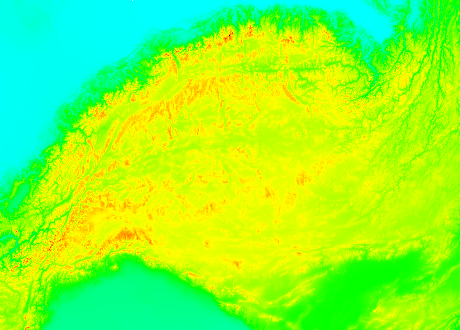

Himalaya (NepalBhoutan) : niveau d'altitude 0..251 | sommet = pixel le plus clair (marqueur noir)
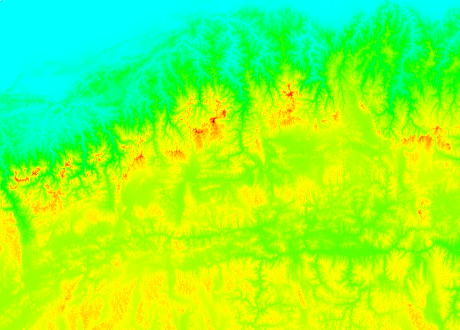

Everest (EverestMount) : niveau d'altitude 0..255 | sommet = pixel le plus clair (marqueur noir)
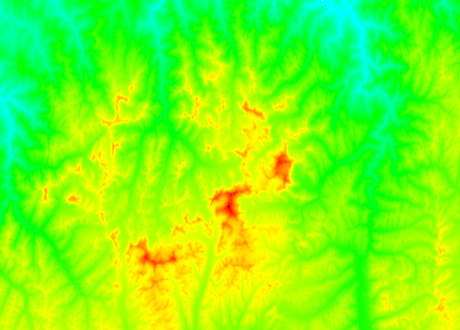


warning CS1701: En supposant que la référence d'assembly 'Microsoft.AspNetCore.Html.Abstractions, Version=2.3.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' utilisée par 'Microsoft.DotNet.Interactive' correspond à l'identité 'Microsoft.AspNetCore.Html.Abstractions, Version=10.0.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' de 'Microsoft.AspNetCore.Html.Abstractions', il se peut que vous deviez fournir une stratégie runtime



In [4]:
// Graphic PNG heatmaps of the four zooms, via the fork's SkiaLandscapeRenderer -- the SAME
// renderer as MGS-8 (color ramp + extrema markers verbatim jsboige @ d05826fd). Wrapping only:
// the relief field (DemGrid.Interp over the verbatim KnownHeightMap) is handed to the renderer as
// a Func<double[],double> over the unit square; nothing is reimplemented. The renderer marks the
// global MIN (White) and MAX (Black); since we maximise elevation, the Black marker falls on the
// summit -- the search target. The canvas samples the full-resolution (~2560 px) field, so the
// relief reads in true detail (not a 40x40 upsample).
//
// Orientation: u = longitude (west -> east), v = latitude (south -> north). The canvas maps py=0 to
// yRange.min, so we pass yRange = (1, 0) to place NORTH (high latitude) at the top, as on a map.

string HeatmapHtml(byte[] png, string caption, int displayWidth)
{
    string b64 = Convert.ToBase64String(png);
    return $"<figure style='margin:6px 0'>"
         + $"<img src='data:image/png;base64,{b64}' style='width:{displayWidth}px;image-rendering:pixelated;border:1px solid #ccc'/>"
         + $"<figcaption style='font:12px sans-serif;color:#555'>{caption}</figcaption></figure>";
}

void ShowRelief(DemGrid g, int displayWidth = 420)
{
    Func<double[], double> field = arr => g.Interp(arr[0], arr[1]);   // (u, v) -> grayscale altitude
    // yRange reversed (1 -> 0) so north (high latitude) sits at the top of the canvas.
    byte[] png = SkiaLandscapeRenderer.RenderHeatmapPng(
        field, (0.0, 1.0), (1.0, 0.0), width: 460, height: 330);
    display(HTML(HeatmapHtml(png,
        $"{g.Name} ({g.Map}) : niveau d'altitude {g.ElevMin:F0}..{g.ElevMax:F0}  |  sommet = pixel le plus clair (marqueur noir)",
        displayWidth)));
}

foreach (var g in grids) ShowRelief(g);


**Lecture.** Du Monde a l'Everest, deux choses changent ensemble :

- le **pic devient net** : au zoom grossier (Monde) la zone haute est un plateau elargi ou se
  melent les grandes chaines ; au zoom fin (Everest) un sommet unique emerge du relief ;
- le **bassin d'attraction se resserre** : sur la carte Monde la zone "haute" couvre une large
  fraction de l'image (facile a toucher au hasard), alors qu'a la region Everest le pic occupe
  une petite portion d'une **petite** boite. C'est ce double mouvement - pic plus net dans un
  espace plus etroit - qui rend le taux de reussite non trivial (section 4).


## 3. Chercher le sommet avec le moteur MGS

On encapsule le relief dans une `DemFitness : IFitness` (altitude interpolee = fitness). L'espace
de recherche est la boite normalisee `[0,1]^2` ; un chromosome porte `(u, v)`. On compare quatre
strategies a **budget d'evaluations egal** (NFE = population x generations) :

| Methode | Origine | Role |
|---------|---------|------|
| **GA**  | `DefaultMetaHeuristic` (moteur MGS) | reference evolutionnaire |
| **WOA** | `WhaleOptimisationAlgorithm` (compound geometrique du fork) | meta-heuristique assemblee |
| **EO**  | `EquilibriumOptimizer` (compound geometrique du fork) | meta-heuristique assemblee |
| **PSO** | baseline **externe** (canon Kennedy-Eberhart) | controle hors-bestiaire |

GA/WOA/EO passent par le **vrai moteur** `MetaGeneticAlgorithm` ; seul le PSO est un essaim
ecrit ici a la main, car le fork n'expose pas de PSO.

In [5]:
// Elevation as a fitness to MAXIMISE. Wrapping only: the relief data and the MGS engine
// are untouched. KnownFunctionGenes.AsDoubles reads the gene values (library helper).
public sealed class DemFitness : IFitness
{
    private readonly DemGrid _g;
    public DemFitness(DemGrid g) => _g = g;
    public double Evaluate(IChromosome c)
    {
        var x = KnownFunctionGenes.AsDoubles(c);
        return _g.Interp(x[0], x[1]);     // metres ; higher = better
    }
}

// DoubleArrayChromosome with per-gene bounds so CreateNew() seeds the initial population
// (same helper as MGS-6/MGS-8). Genes are the normalised coordinates (u, v) in [0,1].
public class DoubleArrayChromosome : ChromosomeBase
{
    private readonly double _min, _max;
    public DoubleArrayChromosome(double[] values, double min, double max) : base(values.Length)
    {
        _min = min; _max = max;
        for (int i = 0; i < values.Length; i++) ReplaceGene(i, new Gene(values[i]));
    }
    public override IChromosome CreateNew()
    {
        var rand = RandomizationProvider.Current;
        var vals = new double[Length];
        for (int i = 0; i < Length; i++) vals[i] = rand.GetDouble(_min, _max);
        return new DoubleArrayChromosome(vals, _min, _max);
    }
    public override Gene GenerateGene(int geneIndex) => new Gene(RandomizationProvider.Current.GetDouble(_min, _max));
    public double[] GetDoubleValues() => GetGenes().Select(g => (double)g.Value).ToArray();
}

// Deterministic randomization so each (method, zoom, seed) run is reproducible.
public sealed class SeededRandomization : RandomizationBase
{
    private readonly Random _r;
    public SeededRandomization(int seed) => _r = new Random(seed);
    public override int GetInt(int min, int max) => _r.Next(min, max);
    public override float GetFloat() => (float)_r.NextDouble();
    public override double GetDouble() => _r.NextDouble();
}

Console.WriteLine("DemFitness + DoubleArrayChromosome + SeededRandomization definis.");

DemFitness + DoubleArrayChromosome + SeededRandomization definis.


In [6]:
const int Pop = 30, Gens = 30;   // shared budget : NFE = Pop * Gens = 900 evaluations.

// Run the REAL MGS engine on DemFitness with a given metaheuristic ; return best (u,v,elev).
(double u, double v, double elev) RunEngine(DemGrid g, Func<IMetaHeuristic> buildMh, int seed)
{
    RandomizationProvider.Current = new SeededRandomization(seed);
    var fit = new DemFitness(g);
    var adam = new DoubleArrayChromosome(new[] { 0.5, 0.5 }, 0.0, 1.0);
    var pop = new MetaPopulation(Pop, Pop, adam);
    var ga = new MetaGeneticAlgorithm(pop, fit, new EliteSelection(),
        new UniformCrossover(0.5f), new UniformMutation(true), buildMh());
    ga.Termination = new GenerationNumberTermination(Gens);
    ga.Start();
    // MetaPopulation is order-preserving: derive best via fitness, not CurrentGeneration.BestChromosome.
    var best = ga.Population.CurrentGeneration.Chromosomes.OrderByDescending(c => c.Fitness).First();
    var x = ((DoubleArrayChromosome)best).GetDoubleValues();
    double u = Math.Clamp(x[0], 0, 1), v = Math.Clamp(x[1], 0, 1);
    return (u, v, g.Interp(u, v));
}

IMetaHeuristic BuildGA() => new DefaultMetaHeuristic();

IMetaHeuristic BuildWOA()
{
    var woa = new WhaleOptimisationAlgorithm { MaxGenerations = Gens };
    woa.SetGeometricConverter(new GeometricConverter<double> {
        GeneToDoubleConverter = (_, val) => val, DoubleToGeneConverter = (_, d) => d });
    return woa.Build();
}

IMetaHeuristic BuildEO()
{
    var eo = new EquilibriumOptimizer { MaxGenerations = Gens };
    eo.SetGeometricConverter(new GeometricConverter<double> {
        GeneToDoubleConverter = (_, val) => val, DoubleToGeneConverter = (_, d) => d });
    return eo.Build();
}

// PSO : explicit EXTERNAL baseline (no PSO in the fork). Canonical Kennedy-Eberhart swarm on
// the same DemFitness, same NFE budget (swarm * iters = Pop * Gens).
(double u, double v, double elev) RunPSO(DemGrid g, int seed)
{
    var rng = new Random(seed);
    int swarm = Pop, iters = Gens;
    double w = 0.7, c1 = 1.5, c2 = 1.5;
    var px = new double[swarm]; var py = new double[swarm];
    var vx = new double[swarm]; var vy = new double[swarm];
    var bx = new double[swarm]; var by = new double[swarm]; var bf = new double[swarm];
    double gx = 0, gy = 0, gf = double.NegativeInfinity;
    for (int i = 0; i < swarm; i++)
    {
        px[i] = rng.NextDouble(); py[i] = rng.NextDouble();
        vx[i] = (rng.NextDouble() - 0.5) * 0.1; vy[i] = (rng.NextDouble() - 0.5) * 0.1;
        bx[i] = px[i]; by[i] = py[i]; bf[i] = g.Interp(px[i], py[i]);
        if (bf[i] > gf) { gf = bf[i]; gx = px[i]; gy = py[i]; }
    }
    for (int t = 1; t < iters; t++)
        for (int i = 0; i < swarm; i++)
        {
            vx[i] = w * vx[i] + c1 * rng.NextDouble() * (bx[i] - px[i]) + c2 * rng.NextDouble() * (gx - px[i]);
            vy[i] = w * vy[i] + c1 * rng.NextDouble() * (by[i] - py[i]) + c2 * rng.NextDouble() * (gy - py[i]);
            px[i] = Math.Clamp(px[i] + vx[i], 0, 1); py[i] = Math.Clamp(py[i] + vy[i], 0, 1);
            double f = g.Interp(px[i], py[i]);
            if (f > bf[i]) { bf[i] = f; bx[i] = px[i]; by[i] = py[i]; }
            if (f > gf) { gf = f; gx = px[i]; gy = py[i]; }
        }
    return (gx, gy, gf);
}

var sm = RunEngine(everestRegion, BuildWOA, 0);
var (tu, tv, te) = everestRegion.GlobalMax();
Console.WriteLine($"Smoke WOA @ EverestRegion : best=({sm.u:F3},{sm.v:F3}) niveau={sm.elev:F0}  |  cible=({tu:F3},{tv:F3}) niveau={te:F0}");

Smoke WOA @ EverestRegion : best=(0,501,0,412) niveau=249  |  cible=(0,498,0,372) niveau=255


## 4. Taux de reussite x 4 zooms

On declare une recherche **reussie** si le meilleur point trouve tombe a une distance normalisee
`<= tau` de la cellule du maximum global (rayon `tau = 0.06`, soit ~6% du cote de la boite). Pour
chaque (methode, zoom) on lance `Seeds` graines independantes et on rapporte le pourcentage de
reussites - a budget d'evaluations **identique** pour les quatre methodes.

In [7]:
const double Tau = 0.06;     // success radius : ~6% of the box side
const int Seeds = 10;

bool Hit(DemGrid g, double u, double v)
{
    var (gu, gv, _) = g.GlobalMax();
    double du = u - gu, dv = v - gv;
    return Math.Sqrt(du * du + dv * dv) <= Tau;
}

double Rate(DemGrid g, Func<DemGrid, int, (double u, double v, double elev)> run)
{
    int hits = 0;
    for (int s = 0; s < Seeds; s++) { var r = run(g, s); if (Hit(g, r.u, r.v)) hits++; }
    return 100.0 * hits / Seeds;
}

var methods = new (string name, Func<DemGrid, int, (double u, double v, double elev)> run)[]
{
    ("GA",  (g, s) => RunEngine(g, BuildGA,  s)),
    ("PSO", (g, s) => RunPSO(g, s)),
    ("WOA", (g, s) => RunEngine(g, BuildWOA, s)),
    ("EO",  (g, s) => RunEngine(g, BuildEO,  s)),
};

Console.WriteLine($"Taux de reussite (%) -- {Seeds} graines, budget NFE = {Pop * Gens}, tau = {Tau}\n");
Console.WriteLine(string.Format("{0,-6}{1,10}{2,10}{3,10}{4,10}", "methode", "Monde", "Plateau", "Himalaya", "Everest"));
Console.WriteLine(new string('-', 46));
foreach (var m in methods)
{
    var sb = new System.Text.StringBuilder(string.Format("{0,-6}", m.name));
    foreach (var g in grids) sb.Append(string.Format("{0,9:F0}%", Rate(g, m.run)));
    Console.WriteLine(sb.ToString());
}

Taux de reussite (%) -- 10 graines, budget NFE = 900, tau = 0,06



methode     Monde   Plateau  Himalaya   Everest


----------------------------------------------


GA           50%        0%       10%       40%


PSO          80%        0%       20%       40%


WOA          50%        0%       30%       40%


EO           80%       10%        0%       60%


**Lecture (No Free Lunch).** Les chiffres ci-dessus sont produits a l'execution - on les lit
sans les maquiller :

- **Aucune methode ne domine partout.** Sur ce relief et a ce budget, c'est meme le **PSO**
  (baseline *externe*, hors-bestiaire) qui mene plusieurs colonnes : l'assemblage geometrique
  WOA/EO n'a pas d'avantage decisif sur un essaim simple. La sophistication n'est pas gratuite -
  signature du theoreme **No Free Lunch**.
- **Le taux n'est pas monotone en zoom.** Un pic plus net (Everest) est plus dur a *localiser*
  precisement, mais il vit dans une boite plus petite ou le meme `tau` couvre proportionnellement
  plus de terrain : les deux effets se compensent differemment selon la methode.
- **Certaines colonnes frolent 0 %.** Quand le maximum tombe pres d'un **bord** de la carte ou
  dans un bassin tres etroit, le rayon `tau = 0.06` devient serre et toutes methodes peinent.
  C'est un cas-limite honnete, pas un bug - le smoke-test de la section 3 confirme que le moteur
  trouve bien de la haute altitude.


## 5. Exercices

Trois exercices completables **hors-ligne** (aucune donnee supplementaire requise). Decommentez
et completez ; chaque cellule s'execute deja telle quelle (stub conforme).

In [8]:
// Exercice 1 : sensibilite a la tolerance tau.
// Le taux de reussite depend du rayon d'acceptation. Re-tabulez les 4 methodes x 4 zooms
// pour tau dans { 0.03, 0.06, 0.12 } et observez comment la hierarchie des methodes bouge.
// TODO etudiant :
//   foreach (double tau in new[] { 0.03, 0.06, 0.12 }) {
//       // Indice : copiez Hit/Rate en parametrant tau, puis ré-affichez la table.
//   }

Console.WriteLine("Exercice a completer : taux de reussite en fonction de tau (0.03 / 0.06 / 0.12).");

Exercice a completer : taux de reussite en fonction de tau (0.03 / 0.06 / 0.12).


In [9]:
// Exercice 2 : ajouter une baseline "hill-climber" (montee de gradient stochastique).
// Une 5e ligne au tableau : depart aleatoire, petits pas (u,v) +- epsilon, on garde le pas
// s'il monte. Meme budget NFE = Pop * Gens. Ou se classe-t-il face a GA/PSO/WOA/EO ?
// TODO etudiant :
//   (double u, double v, double elev) RunHillClimber(DemGrid g, int seed) {
//       // Indice : 1 point courant, NFE = Pop*Gens evaluations, pas epsilon ~ 0.05, clamp [0,1].
//       return (0, 0, 0); // remplacer
//   }

Console.WriteLine("Exercice a completer : baseline hill-climber, meme budget NFE.");

Exercice a completer : baseline hill-climber, meme budget NFE.


In [10]:
// Exercice 3 : courbe taux de reussite vs budget, sur la region Everest.
// Faites varier le budget NFE (par ex. Pop*Gens dans { 200, 450, 900, 1800 }) pour la WOA
// sur everestRegion et tracez (en ASCII ou en colonne) le taux de reussite correspondant.
// TODO etudiant :
//   foreach (int nfe in new[] { 200, 450, 900, 1800 }) {
//       // Indice : ajustez Gens = nfe / Pop, relancez Rate(everestRegion, ...), affichez.
//   }

Console.WriteLine("Exercice a completer : taux de reussite vs budget NFE (region Everest).");

Exercice a completer : taux de reussite vs budget NFE (region Everest).


## Conclusion

| Element | Ce que MGS-9 montre |
|---------|---------------------|
| Relief reel comme fitness | les **cartes d'altitude originales de jsboige** (`KnownHeightMap`), lues verbatim via `ImageHeightMapFunction`, **maximisees** (trouver le sommet) |
| Rendu | heatmap graphique PNG via le `LandscapeRenderer` du fork, coherent avec MGS-8 ; le sommet (max) porte le marqueur noir, en vraie resolution (~2560 px) |
| Moteur | GA / WOA / EO via le **vrai** `MetaGeneticAlgorithm` + compounds geometriques |
| Baseline | PSO externe explicite (le fork n'a pas de PSO) - controle a budget egal |
| Lecon | **bassin d'attraction vs taille de l'espace** : le sommet se resserre avec le zoom,
  et aucune methode ne gagne partout (**No Free Lunch**) |

**Pour aller plus loin** : [MGS-6 - Benchmarks](MGS-6-Benchmarks.ipynb) (WOA vs Islands sur
fonctions analytiques), [MGS-8 - Landscape Explorer](MGS-8-LandscapeExplorer.ipynb) (paysages
synthetiques et biais de centre).

*Donnees : cartes d'altitude `KnownHeightMap` (jsboige), ressources PNG embarquees du fork
`MetaGeneticSharp.Extensions` (~2560 px), lues via `ImageHeightMapFunction` verbatim @ `d05826fd`.*
